## UPLOAD DATA SET
run libraries   
upload data sets

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [13]:
df = pd.read_csv("Student_Performance.csv")

## EDA  AND PREPROCESSING 
preprocess data but this data is preprocessed 

## CLUSTERING
##### 1) split data

In [14]:
df=df.drop(columns=['Sr. No'])
scalar=StandardScaler()
df=scalar.fit_transform(df)

##### 2) PCA 
principle component analysis
reduce number of dimensions to give max information   
It’s a dimensionality reduction technique used to simplify data while keeping as much important information as possible.  
auto make dimensions through maths and stats   
on the other hand we have feature engineering that allows u to tell dimensional parameters  

In [15]:
df=PCA(n_components=2).fit_transform(df)
df[:5]

array([[ 0.25565447,  0.62975614],
       [ 0.97710277,  0.7855595 ],
       [-0.62129696, -0.8100778 ],
       [ 1.37373263,  1.98290394],
       [ 2.75830902,  0.89238661]])

##### 3) Visualize

<function matplotlib.pyplot.show(close=None, block=None)>

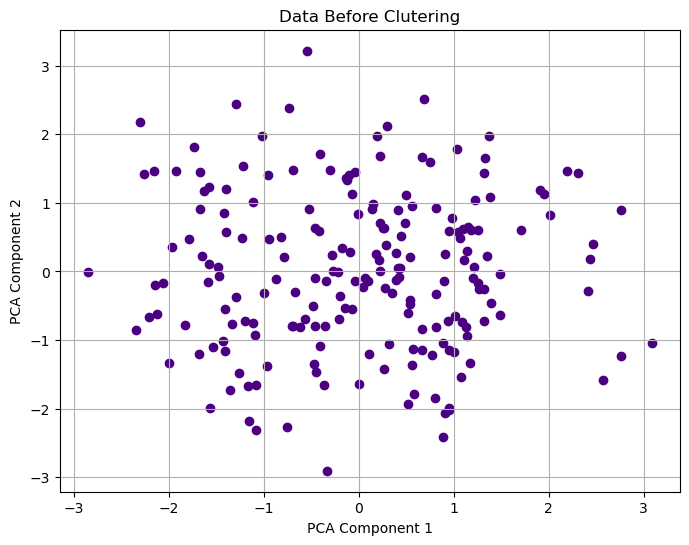

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(df[:,0],df[:,1],c='indigo')
plt.title('Data Before Clutering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.show

##### 4) GRAPH 

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

<function matplotlib.pyplot.show(close=None, block=None)>

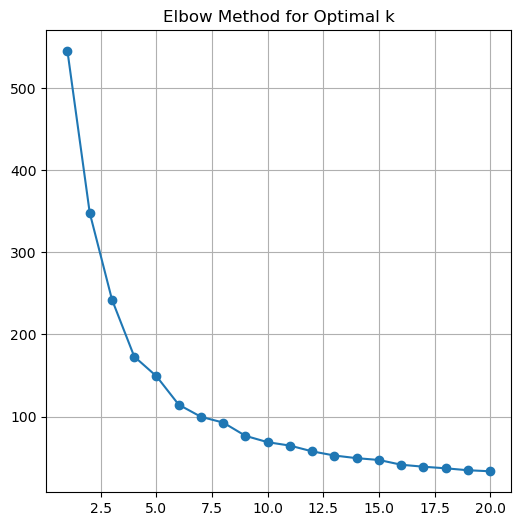

In [ ]:
inertia=[]
k_range=range(1,21)
for k in k_range:
    km=KMeans(n_clusters=k,random_state=42)
    km.fit(df)
    inertia.append(km.inertia_)

    K=5
kmeans=KMeans(n_clusters=k,random_state=42)
clusters=kmeans.fit_predict(df)

plt.figure(figsize=(8,6))
plt.plot(k_range,inertia,marker='o')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show
#have some k value KMenas that would give optimal value to find that optimal value we have some method of ELBOW Method 
#graph shape is like elbow  and whee the line is starting to be in straight that means that is our optimal value

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<function matplotlib.pyplot.show(close=None, block=None)>

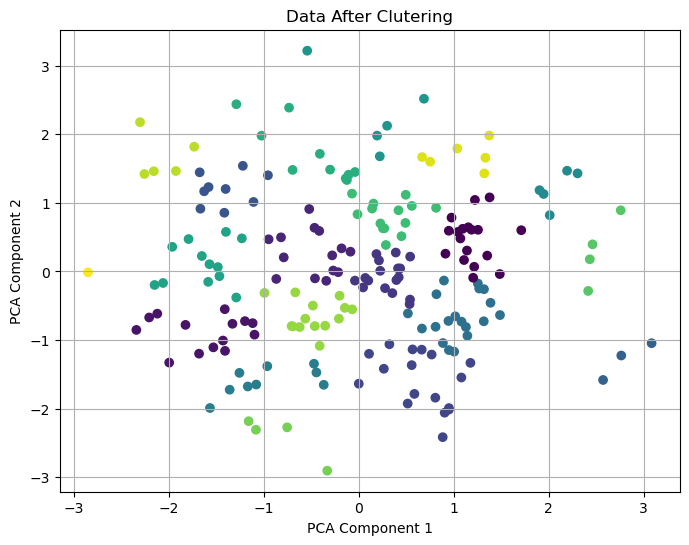

In [21]:
K=5
kmeans=KMeans(n_clusters=k,random_state=42)
clusters=kmeans.fit_predict(df)

plt.figure(figsize=(8,6))
plt.scatter(df[:,0],df[:,1],c=clusters,cmap='viridis') #.scatter function
plt.title('Data After Clutering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.show 

In [22]:
sil_score = silhouette_score(df, clusters)
print(f"Silhouette Score: {sil_score:.3f}")
db_index = davies_bouldin_score(df, clusters)
print(f"Davies-Bouldin Index: {db_index:.3f}")
ch_index = calinski_harabasz_score(df, clusters)
print(f"Calinski-Harabasz Index: {ch_index:.3f}")
inertia = kmeans.inertia_
print(f"Inertia (within-cluster sum of squares): {inertia:.2f}")


Silhouette Score: 0.360
Davies-Bouldin Index: 0.786
Calinski-Harabasz Index: 145.105
Inertia (within-cluster sum of squares): 33.39
